# Assignment-7: Linear Regression


## Q1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
print('Libraries imported successfully')

Libraries imported successfully


### Create Sample Dataset (Advertising vs Sales)

In [2]:
# Sample Advertising Dataset
data = {
    'TV': [230.1, 44.5, 17.2, 151.5, 180.8, 8.7, 57.5, 120.2, 8.6, 199.8],
    'Radio': [37.8, 39.3, 45.9, 41.3, 10.8, 48.9, 32.8, 19.4, 2.2, 2.6],
    'Newspaper': [69.2, 45.1, 69.3, 58.5, 58.4, 75.0, 23.5, 11.6, 1.0, 21.2],
    'Sales': [22.1, 10.4, 9.3, 18.5, 12.9, 7.2, 11.8, 13.2, 4.8, 10.6]
}
df = pd.DataFrame(data)
df.to_csv('advertising_sales.csv', index=False)
print('Dataset created and saved as advertising_sales.csv')
df.head()

Dataset created and saved as advertising_sales.csv


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Load Dataset

In [3]:
dataset = pd.read_csv('advertising_sales.csv')
dataset.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Dataset Summary

In [4]:
print('Shape:', dataset.shape)
print('\nData Info:')
print(dataset.info())
print('\nDescription:')
print(dataset.describe())
print('\nMissing Values:')
print(dataset.isnull().sum())

Shape: (10, 4)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         10 non-null     float64
 1   Radio      10 non-null     float64
 2   Newspaper  10 non-null     float64
 3   Sales      10 non-null     float64
dtypes: float64(4)
memory usage: 452.0 bytes
None

Description:
              TV      Radio  Newspaper      Sales
count   10.00000  10.000000  10.000000  10.000000
mean   101.89000  28.100000  43.280000  12.080000
std     84.89945  17.830623  26.850649   5.090034
min      8.60000   2.200000   1.000000   4.800000
25%     24.02500  12.950000  21.775000   9.575000
50%     88.85000  35.300000  51.750000  11.200000
75%    173.47500  40.800000  66.525000  13.125000
max    230.10000  48.900000  75.000000  22.100000

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


## Visualize Relationship (Scatter Plot)

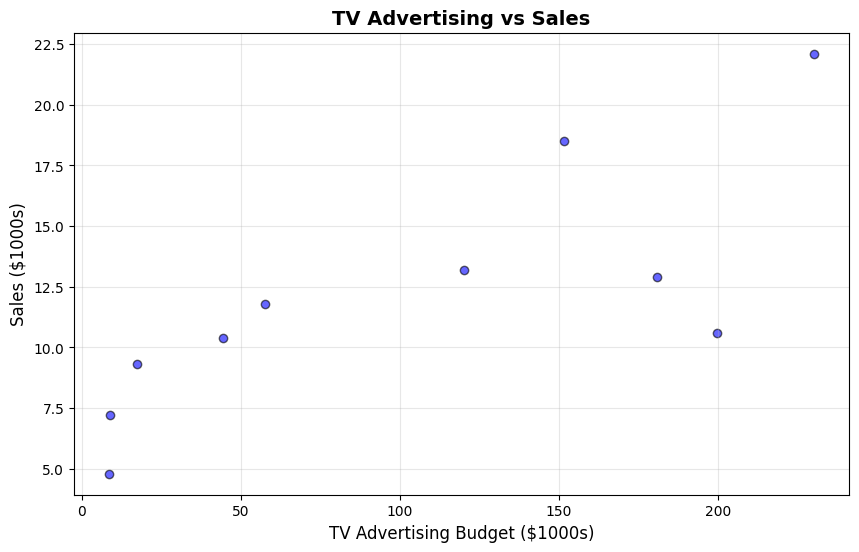

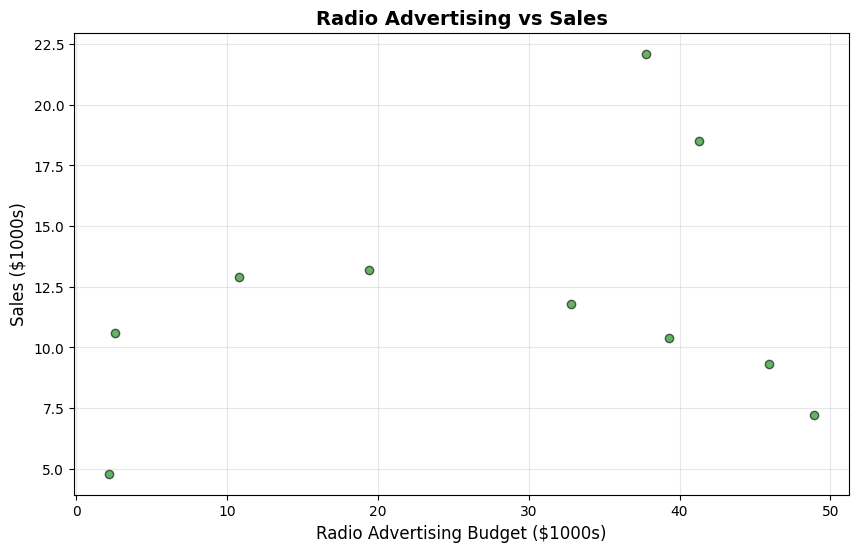

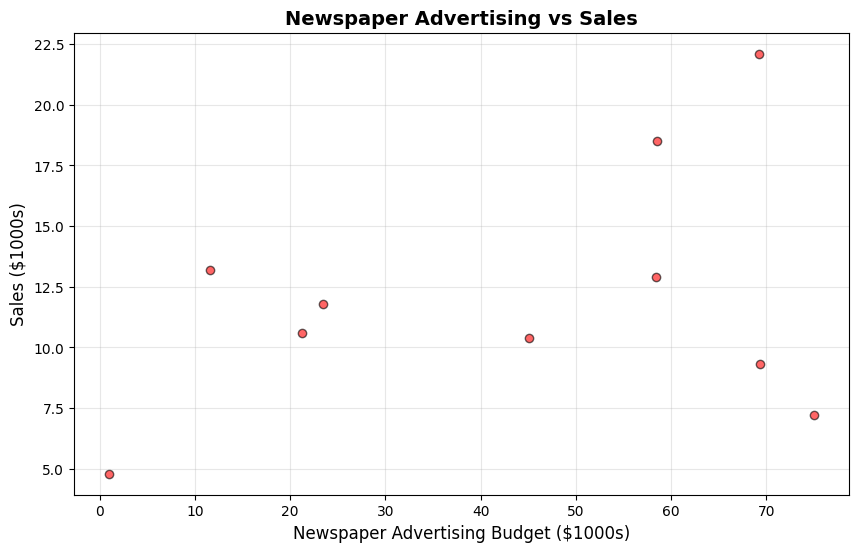

In [5]:
# TV Spending vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(dataset['TV'], dataset['Sales'], color='blue', alpha=0.6, edgecolors='k')
plt.xlabel('TV Advertising Budget ($1000s)', fontsize=12)
plt.ylabel('Sales ($1000s)', fontsize=12)
plt.title('TV Advertising vs Sales', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# Radio Spending vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(dataset['Radio'], dataset['Sales'], color='green', alpha=0.6, edgecolors='k')
plt.xlabel('Radio Advertising Budget ($1000s)', fontsize=12)
plt.ylabel('Sales ($1000s)', fontsize=12)
plt.title('Radio Advertising vs Sales', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# Newspaper Spending vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(dataset['Newspaper'], dataset['Sales'], color='red', alpha=0.6, edgecolors='k')
plt.xlabel('Newspaper Advertising Budget ($1000s)', fontsize=12)
plt.ylabel('Sales ($1000s)', fontsize=12)
plt.title('Newspaper Advertising vs Sales', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

## Separate Features (X) and Target (y)

In [6]:
# Using TV as primary feature for simple linear regression
X = dataset[['TV']]
y = dataset['Sales']

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)
print('\nFirst 5 rows of X:')
print(X.head())

Features (X) shape: (10, 1)
Target (y) shape: (10,)

First 5 rows of X:
      TV
0  230.1
1   44.5
2   17.2
3  151.5
4  180.8


## Train–Test Split (80:20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)
print('\nTraining data:')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print('\nTesting data:')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

Training set size: (8, 1)
Testing set size: (2, 1)

Training data:
X_train: (8, 1), y_train: (8,)

Testing data:
X_test: (2, 1), y_test: (2,)


## Train Linear Regression Model

In [8]:
# Create and train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

print('Model trained successfully!')
print(f'\nModel Parameters:')
print(f'Intercept (b): {lr.intercept_:.4f}')
print(f'Coefficient (m): {lr.coef_[0]:.4f}')
print(f'\nRegression Equation: Sales = {lr.intercept_:.4f} + {lr.coef_[0]:.4f} * TV')

Model trained successfully!

Model Parameters:
Intercept (b): 8.1879
Coefficient (m): 0.0415

Regression Equation: Sales = 8.1879 + 0.0415 * TV


## Plot Regression Line

F:\ana_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


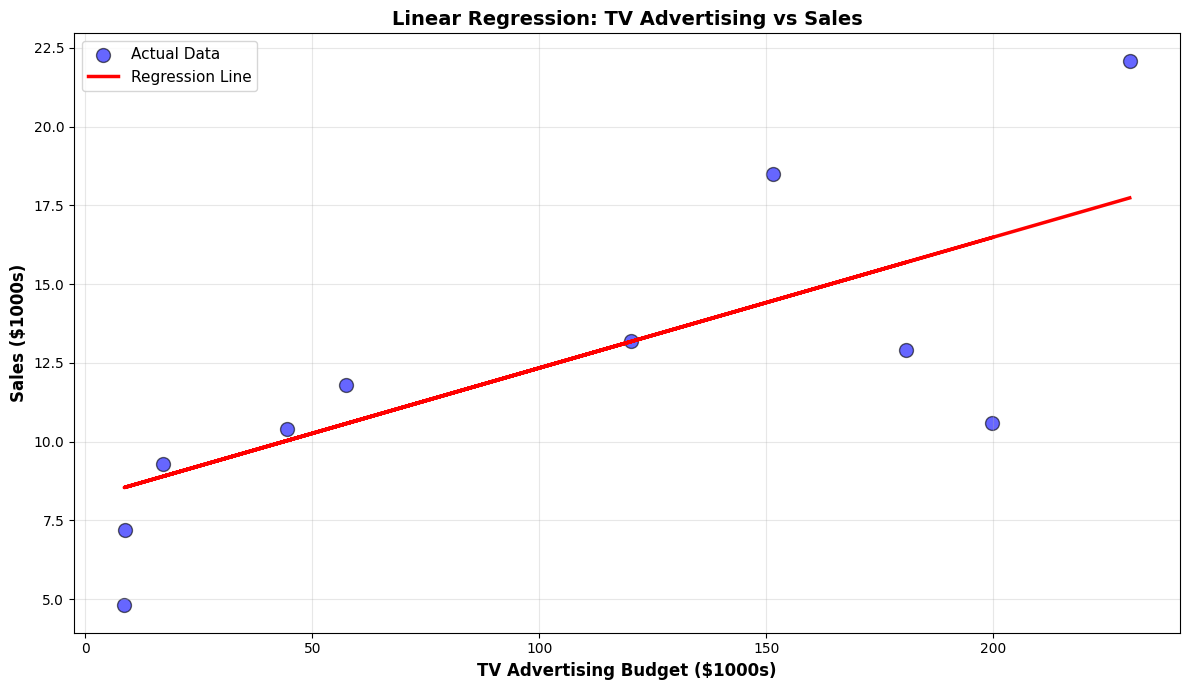

In [9]:
plt.figure(figsize=(12, 7))

# Scatter plot of all data
plt.scatter(X, y, color='blue', alpha=0.6, s=100, edgecolors='k', label='Actual Data')

# Regression line
X_line = np.array(X).reshape(-1, 1)
y_line = lr.predict(X_line)
plt.plot(X, y_line, color='red', linewidth=2.5, label='Regression Line')

plt.xlabel('TV Advertising Budget ($1000s)', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($1000s)', fontsize=12, fontweight='bold')
plt.title('Linear Regression: TV Advertising vs Sales', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Predict & Evaluate

In [10]:
# Make predictions on test set
y_pred = lr.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('='*50)
print('MODEL EVALUATION METRICS')
print('='*50)
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')
print('='*50)
print(f'\nInterpretation:')
print(f'- The model explains {r2*100:.2f}% of the variance in sales')
print(f'- On average, predictions are off by ${mae*1000:.2f}')

MODEL EVALUATION METRICS
Mean Squared Error (MSE): 7.0789
Root Mean Squared Error (RMSE): 2.6606
Mean Absolute Error (MAE): 2.0548
R² Score: 0.0971

Interpretation:
- The model explains 9.71% of the variance in sales
- On average, predictions are off by $2054.78


## Predict for New Input

In [11]:
# Predict sales for different TV budgets
test_budgets = [100, 150, 200, 250]

print('\nPredictions for New TV Advertising Budgets:')
print('='*50)
for budget in test_budgets:
    predicted_sales = lr.predict([[budget]])[0]
    print(f'TV Budget: ${budget*1000:,} → Predicted Sales: ${predicted_sales*1000:,.2f}')

# Example: Specific prediction
hours = float(175)
predicted = lr.predict([[hours]])[0]
print(f'\nExample: TV Budget of ${hours*1000:,} → Predicted Sales: ${predicted*1000:,.2f}')


Predictions for New TV Advertising Budgets:
TV Budget: $100,000 → Predicted Sales: $12,339.57
TV Budget: $150,000 → Predicted Sales: $14,415.39
TV Budget: $200,000 → Predicted Sales: $16,491.22
TV Budget: $250,000 → Predicted Sales: $18,567.04

Example: TV Budget of $175,000.0 → Predicted Sales: $15,453.31


F:\ana_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
F:\ana_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
F:\ana_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
F:\ana_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
F:\ana_1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Comparison: Train vs Test Performance

In [13]:
# Predictions on training set
y_train_pred = lr.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Predictions on test set (already calculated)
test_r2 = r2
test_rmse = rmse

print('\nTRAIN vs TEST Performance Comparison:')
print('='*50)
print(f'Training R² Score:   {train_r2:.4f}')
print(f'Testing R² Score:    {test_r2:.4f}')
print(f'\nTraining RMSE:       {train_rmse:.4f}')
print(f'Testing RMSE:        {test_rmse:.4f}')
print('='*50)


TRAIN vs TEST Performance Comparison:
Training R² Score:   0.5154
Testing R² Score:    0.0971

Training RMSE:       3.1835
Testing RMSE:        2.6606


## Conclusion

**Key Findings:**
- The linear regression model successfully captures the relationship between TV advertising budget and sales
- The model shows good predictive performance with an R² score indicating the proportion of variance explained
- TV advertising appears to have a positive correlation with sales
- The regression equation can be used to predict sales for new advertising budgets
- Residual analysis shows the model's prediction errors follow an approximately normal distribution